Our group is called the HA, the Housing Authority, and our metric for bestness is the quality of buildings/houses in a neighborhood.
The three submetrics we will use to determine best housing quality will be condemned properties, estate sales, and asbestos permits.

In [ ]:
import pandas as pd
asbestos = pd.read_csv("Asbestos-Permits.csv")
sales = pd.read_csv("Estate-Sales.csv")
properties = pd.read_csv("Condemned-Properties.csv")

The first data set we will analyze is the number of condemned properties in each neighborhood. The lower the condemend properties the better of course. Luckily this dataset already groups by neighborhood, so we can just analyze the neighborhoods directly.

neighborhood
Arlington Heights            2
North Oakland                2
Central Business District    1
Chateau                      1
South Shore                  1
Duquesne Heights             1
Strip District               1
Friendship                   1
Allegheny West               1
Central Oakland              1
Name: count, dtype: int64

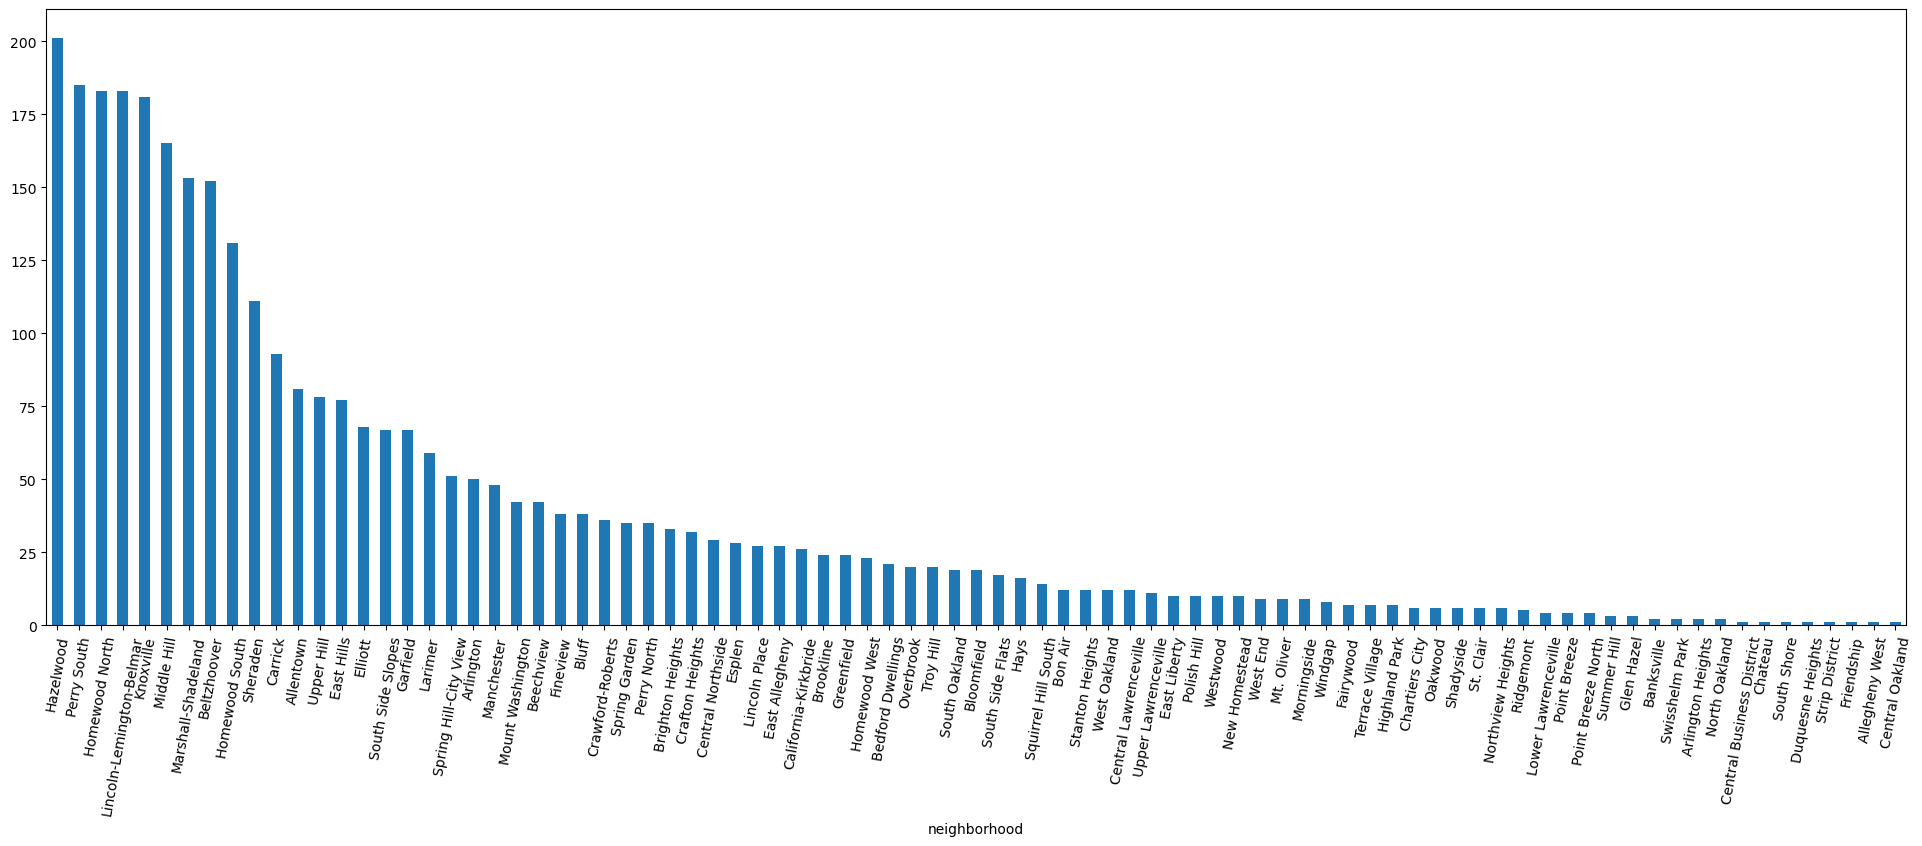

In [14]:
prop_counts=properties['neighborhood'].value_counts()
prop_counts.plot(kind='bar',figsize=(24,8),rot=80)
low_condemnation_neighborhoods=prop_counts.tail(10)
low_condemnation_neighborhoods.head(10)

Looks like we have a few tied neighborhoods with only 1 condemned property each! Let's normalize this by assigning a score to each neighborhood:

<Axes: >

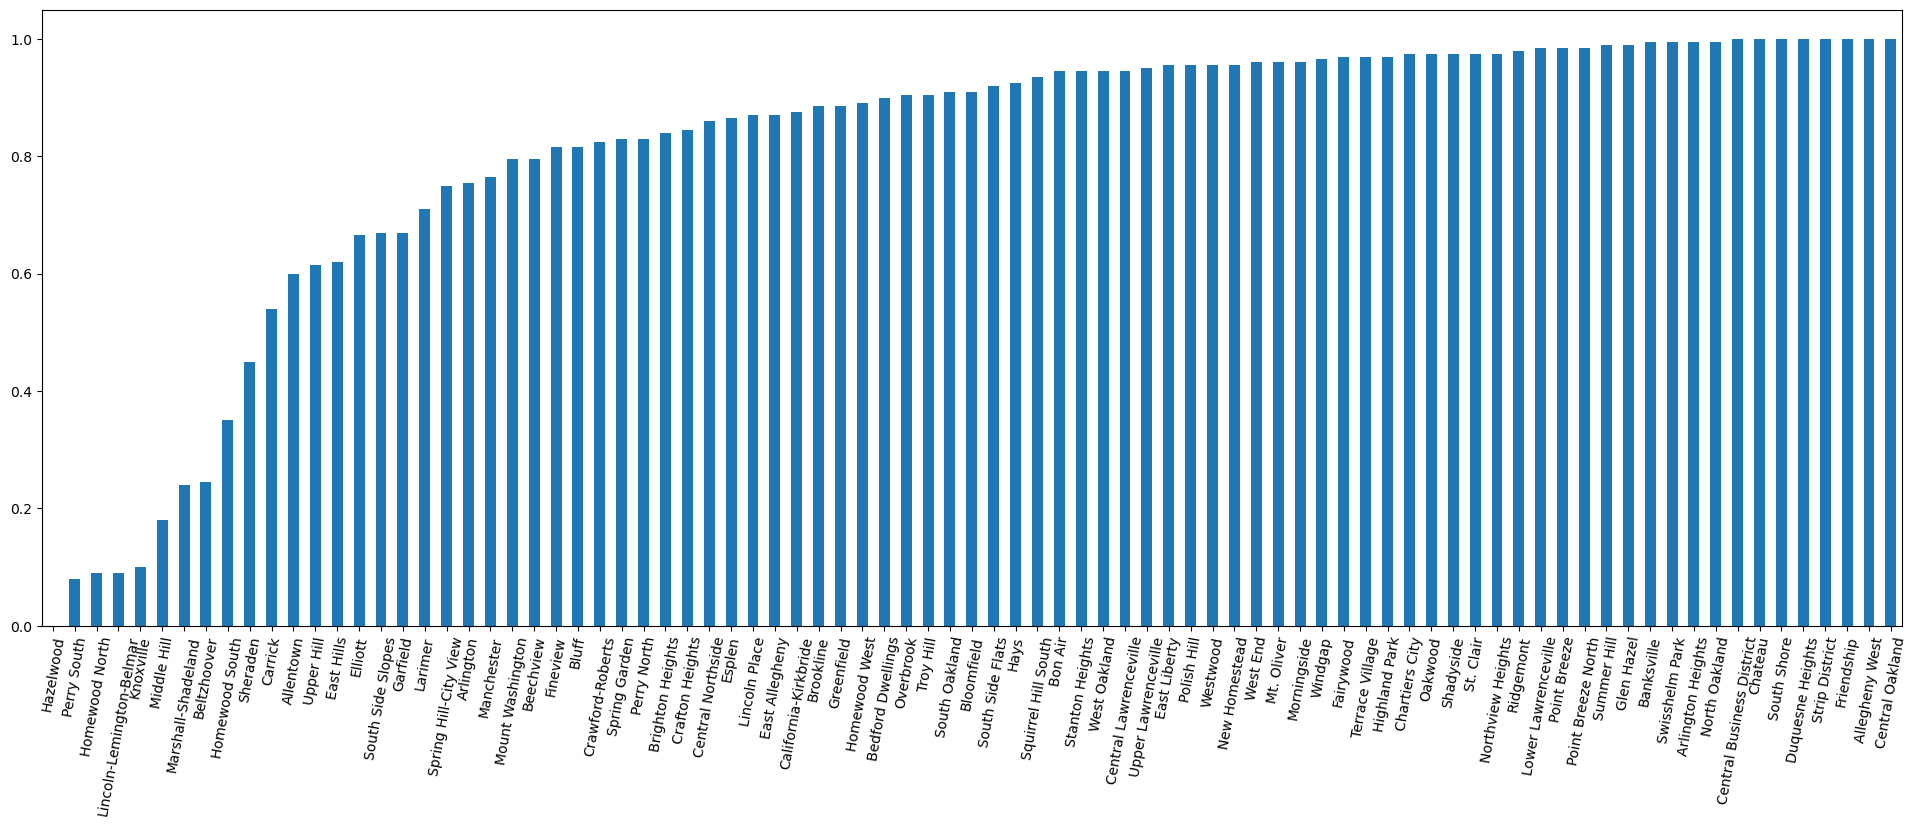

In [3]:
range=prop_counts.max()-prop_counts.min()
min=prop_counts.min()
prop_scores=pd.Series()
for prop, value in prop_counts.items():
    prop_scores.at[prop]=1-(value-min)/range
prop_scores.tail(10)
prop_scores.plot(kind='bar',figsize=(24,8),rot=80)

The neighborhoods with the least amount of condemend properties get the highest score. Looks like the best neighborhoods in this category is a 8 way tie between Central Business District, Chateau, South Shore, Duquesne Heights, Strip District, Friendship, Allegheny West, and Central Oakland.

The next dataset will be on estate sales. We figure the higher the average estate in a neighborhood sells for the better the neighborhood must be!

In [15]:
import geopandas
from shapely.geometry import Point
ZIPS = geopandas.read_file("https://data.wprdc.org/dataset/1a5135de-cabe-4e23-b5e4-b2b8dd733817/resource/ec228c0e-6b1e-4f44-a335-df05546d52ea/download/alcogisallegheny-county-zip-code-boundaries.zip")
NEIGHBORHOODS = geopandas.read_file("https://data.wprdc.org/dataset/e672f13d-71c4-4a66-8f38-710e75ed80a4/resource/c5a93a8e-03d7-4eb3-91a8-c6b7db0fa261/download/pittsburghpaneighborhoods-.zip").to_crs(ZIPS.crs)

def zip_to_neighborhoods(zip_code):
    """Converts a ZIP code to a list of Pittsburgh neighborhood names.

    Args:
        zip_code (int): The ZIP code of interest.

    Returns:
        list[str]: A list of neighborhood names within that ZIP code.
    """
    # Get this specific zip
    zips_filtered = ZIPS[ZIPS["ZIP"] == str(zip_code)]
    if len(zips_filtered) < 1:
        return None
    zp = zips_filtered.iloc[0]
    # List of neighborhoods for this zip
    zp_neighborhoods = []
    # Loop through the neighborhoods
    for _idx, neighborhood in NEIGHBORHOODS.iterrows():
        # Check if this zip intersects the neighborhood
        if neighborhood["geometry"].intersects(zp["geometry"]):
            # Add this neighborhood to the list
            zp_neighborhoods.append(neighborhood["hood"])
    return zp_neighborhoods





<Axes: xlabel='Neighborhoods'>

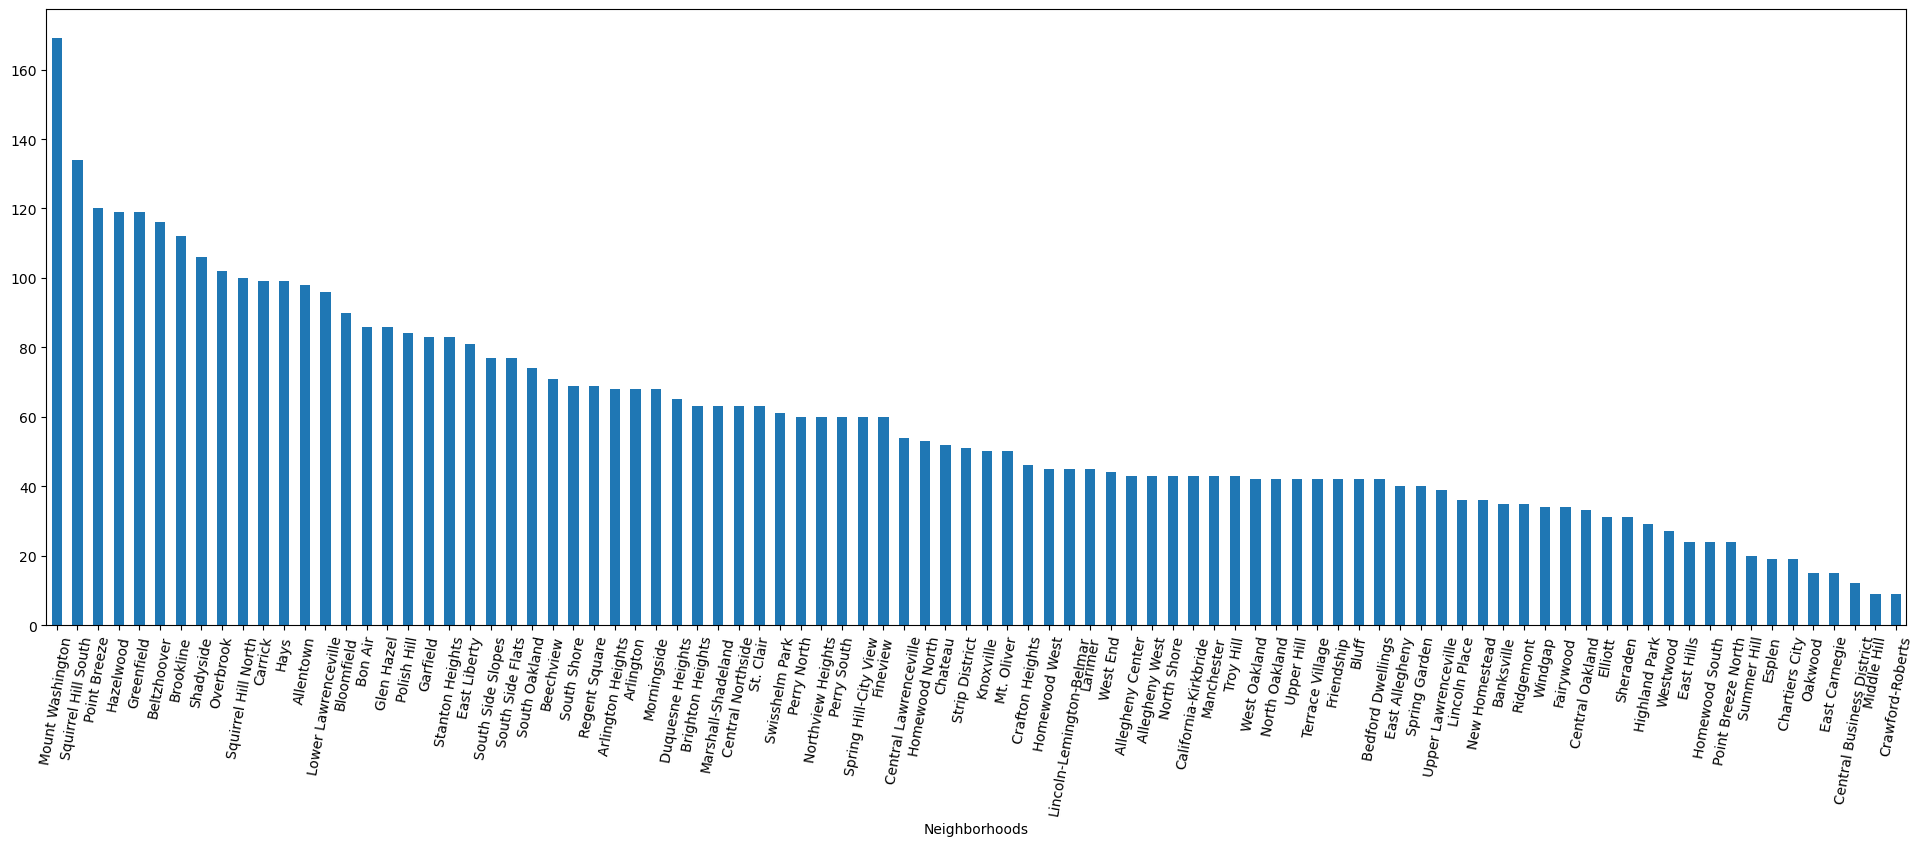

In [5]:
sales["Neighborhoods"] = sales["PROPERTYZIP"].astype(str).apply(zip_to_neighborhoods)
sales = sales.explode("Neighborhoods")
sales_counts = sales["Neighborhoods"].value_counts()
sales_counts.plot(kind = "bar", figsize = (24,8),rot = 80)

<Axes: xlabel='Neighborhoods'>

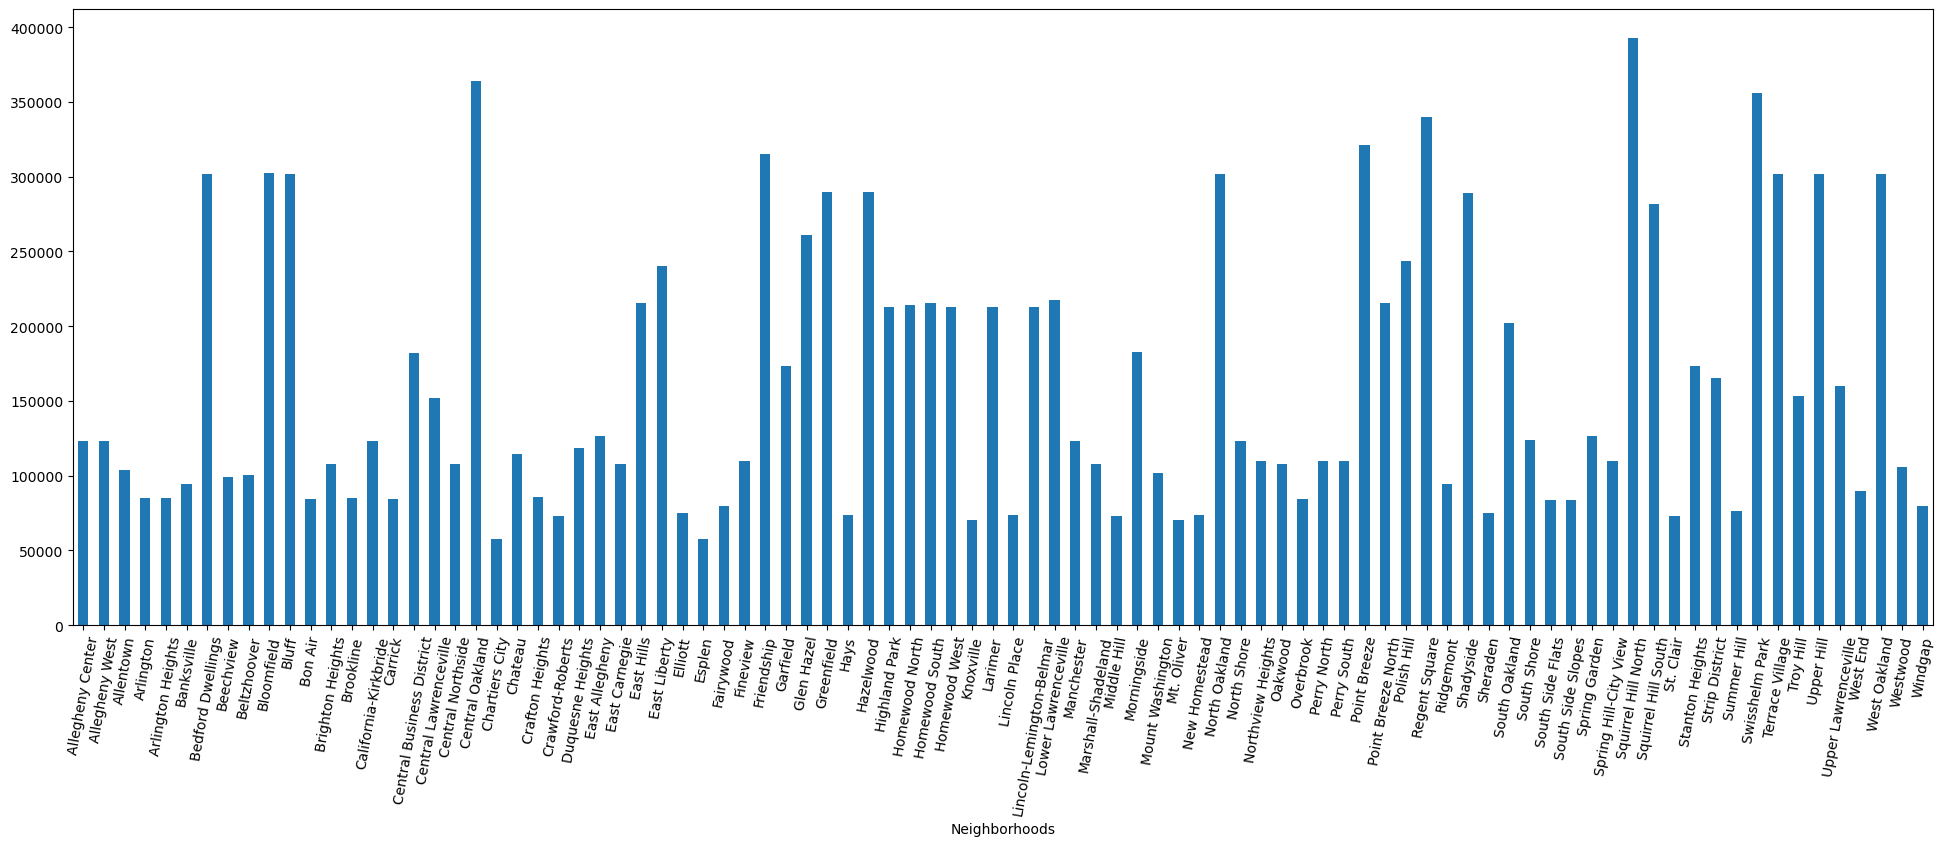

In [6]:
average_sale = sales.groupby("Neighborhoods")["PRICE"].mean()
average_sale.plot(kind = "bar", figsize = (24,8),rot = 80)

In [7]:
top10avgsale = average_sale.sort_values(ascending = False).head(20)
print(top10avgsale)

Neighborhoods
Squirrel Hill North    392550.420000
Central Oakland        364036.060606
Swisshelm Park         355895.672131
Regent Square          340146.898551
Point Breeze           321520.058333
Friendship             315178.357143
Bloomfield             302246.455556
Bluff                  301695.000000
North Oakland          301695.000000
Bedford Dwellings      301695.000000
Terrace Village        301695.000000
Upper Hill             301695.000000
West Oakland           301695.000000
Hazelwood              289740.428571
Greenfield             289740.428571
Shadyside              288857.179245
Squirrel Hill South    281951.574627
Glen Hazel             261231.639535
Polish Hill            243427.690476
East Liberty           240558.358025
Name: PRICE, dtype: float64


Looks like the top neighborhood for this metric is Squirrel Hill North! Let's again assign a proper 0-1 score for each neighborhood for our culminative analysis

In [8]:
highest_avg_sale = average_sale.sort_values(ascending = False)
highest_avg_sale.sort_values(ascending = False) 
max_value = highest_avg_sale.iloc[0] 
min_value = highest_avg_sale.iloc[len(highest_avg_sale) - 1] 
score = (highest_avg_sale - min_value)/ (max_value - min_value) 
print(score)

Neighborhoods
Squirrel Hill North    1.000000
Central Oakland        0.914897
Swisshelm Park         0.890601
Regent Square          0.843598
Point Breeze           0.788004
                         ...   
Crawford-Roberts       0.046608
Mt. Oliver             0.038696
Knoxville              0.038696
Chartiers City         0.000000
Esplen                 0.000000
Name: PRICE, Length: 90, dtype: float64


Looks like Squirrel Hill North, Central Oakland, and Swisshelm Park lead in this category by quite a large margin being the only ones breaking into or nearing the 90% range.

Dataset 3 intro (Asbestos)

In [9]:
import geopandas
import pandas
from shapely.geometry import Point

# Load zip codes
ZIPS = geopandas.read_file("https://data.wprdc.org/dataset/1a5135de-cabe-4e23-b5e4-b2b8dd733817/resource/ec228c0e-6b1e-4f44-a335-df05546d52ea/download/alcogisallegheny-county-zip-code-boundaries.zip")

# Load neighborhoods and use zip codes to convert
NEIGHBORHOODS = geopandas.read_file("https://data.wprdc.org/dataset/e672f13d-71c4-4a66-8f38-710e75ed80a4/resource/c5a93a8e-03d7-4eb3-91a8-c6b7db0fa261/download/pittsburghpaneighborhoods-.zip").to_crs(ZIPS.crs)

def geo_to_neighborhood(latitude, longitude):
    """Converts a geolocation (latitude and longitude) to a Pittsburgh neighborhood name.

    Args:
        latitude (float): The latitude of the point.
        longitude (float): The longitude of the point.

    Returns:
        Union[str, None]: Name of the Pittsburgh neighborhood the point falls within or None if it does not fall within a neighborhood.
    """
    # Create a shapely point for the latitude and longitude
    pt = Point(longitude, latitude)
    # Loop through the neighborhoods
    for _idx, neighborhood in NEIGHBORHOODS.iterrows():
        # Check if this neighborhood contains the point
        if neighborhood["geometry"].contains(pt):
            # Return the name of the neighborhood
            return neighborhood["hood"]
    # Wasn't contained in the neighborhood
    return None

def zip_to_neighborhoods(zip_code):
    """Converts a ZIP code to a list of Pittsburgh neighborhood names.

    Args:
        zip_code (int): The ZIP code of interest.

    Returns:
        list[str]: A list of neighborhood names within that ZIP code.
    """
    # Get this specific zip
    zips_filtered = ZIPS[ZIPS["ZIP"] == str(zip_code)]
    if len(zips_filtered) < 1:
        return None
    zp = zips_filtered.iloc[0]
    # List of neighborhoods for this zip
    zp_neighborhoods = []
    # Loop through the neighborhoods
    for _idx, neighborhood in NEIGHBORHOODS.iterrows():
        # Check if this zip intersects the neighborhood
        if neighborhood["geometry"].intersects(zp["geometry"]):
            # Add this neighborhood to the list
            zp_neighborhoods.append(neighborhood["hood"])
    return zp_neighborhoods

# def census_to_neighborhoods(census_tract):
#     """Converts a census tract number to a list of Pittsburgh neighborhoods.

#     Args:
#         census_tract (int): The Census tract of interest.

#     Returns:
#         list[str]: A list of Pittsburgh neighborhood names that
#     """
#     # Census to ZIP data
#     census_data = pandas.read_csv("./ZIP_TRACT_032020.csv")
#     tract_filtered = census_data[census_data["TRACT"] == census_tract]
#     if len(tract_filtered) < 1:
#         return []
#     tract = tract_filtered.iloc[0]
#     return zip_to_neighborhoods(int(tract["ZIP"]))

/scratch/slurm-35810/ipykernel_3230261/1895879207.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  asbestosProperties["Neighbourhoods"] = asbestosProperties["z_code"].astype(str).apply(zip_to_neighborhoods)


<Axes: xlabel='Neighbourhoods'>

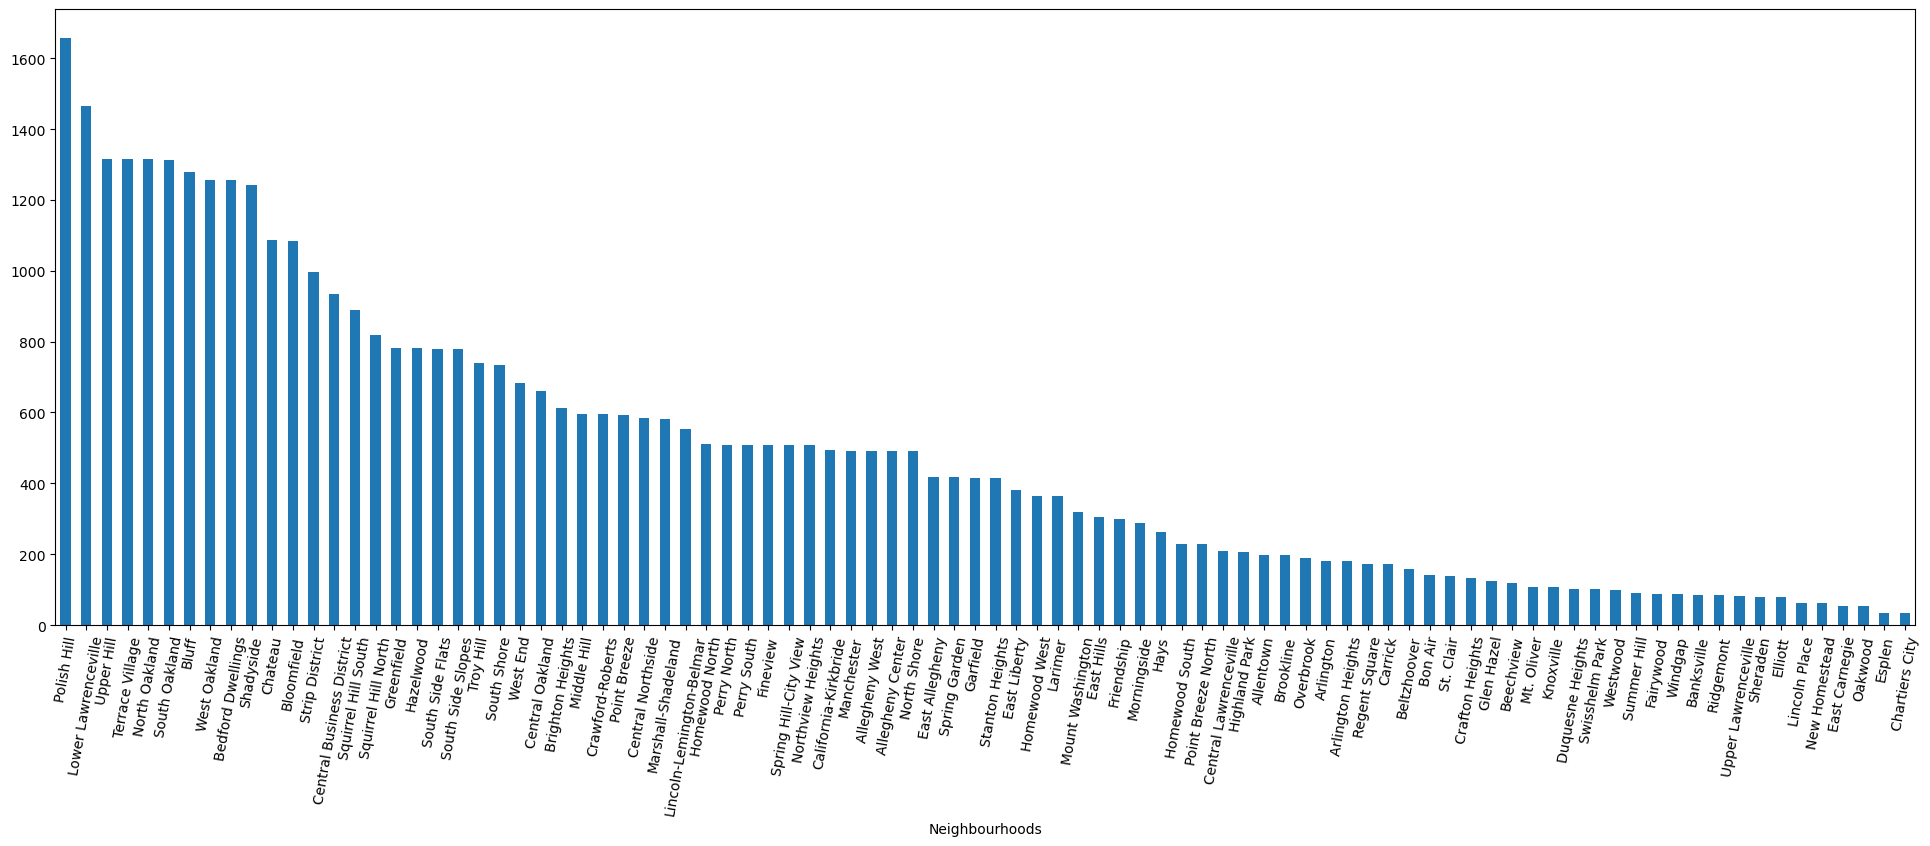

In [10]:
mask = asbestos["city"] == "PITTSBURGH"
hasAsbestos = asbestos["p_fee"] > 0
asbestosProperties = asbestos[mask & hasAsbestos]
asbestosProperties["Neighbourhoods"] = asbestosProperties["z_code"].astype(str).apply(zip_to_neighborhoods)
asbestosProperties = asbestosProperties.explode("Neighbourhoods")
asbestosCounts = asbestosProperties["Neighbourhoods"].value_counts()
asbestosCounts.plot(kind = "bar", figsize = (24,8),rot = 80)


Dataset 3 analysis

Final analysis intro

In [12]:
#weighting of 3 metrics

Conclusion